In [1]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns

path = "../CSV_Files/"

In [2]:
df = pd.DataFrame()
for i in range(8): 
    temp = pd.read_csv(path + f"F{i}M.csv")
    temp["Fault"] = i
    df = pd.concat([df, temp])
    
df.to_csv(path + "df.csv", index=False)

# Box plots on each feature comparing with faults

In [3]:
features = df.columns[1:-1]

# Map numeric fault codes to readable labels for plotting
fault_labels = {
    0: 'Normal',
    1: 'F1', 2: 'F2', 3: 'F3', 4: 'F4',
    5: 'F5', 6: 'F6', 7: 'F7'
}
df['Condition'] = df['Fault'].map(fault_labels)


condition_order = ['Normal', 'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7']
df['Condition'] = pd.Categorical(df['Condition'], categories=condition_order, ordered=True)

/tmp/ipykernel_679461/1556444785.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_679461/1556444785.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_679461/1556444785.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_679461/1556444785.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_679461/1556444785.py:9: FutureWarning

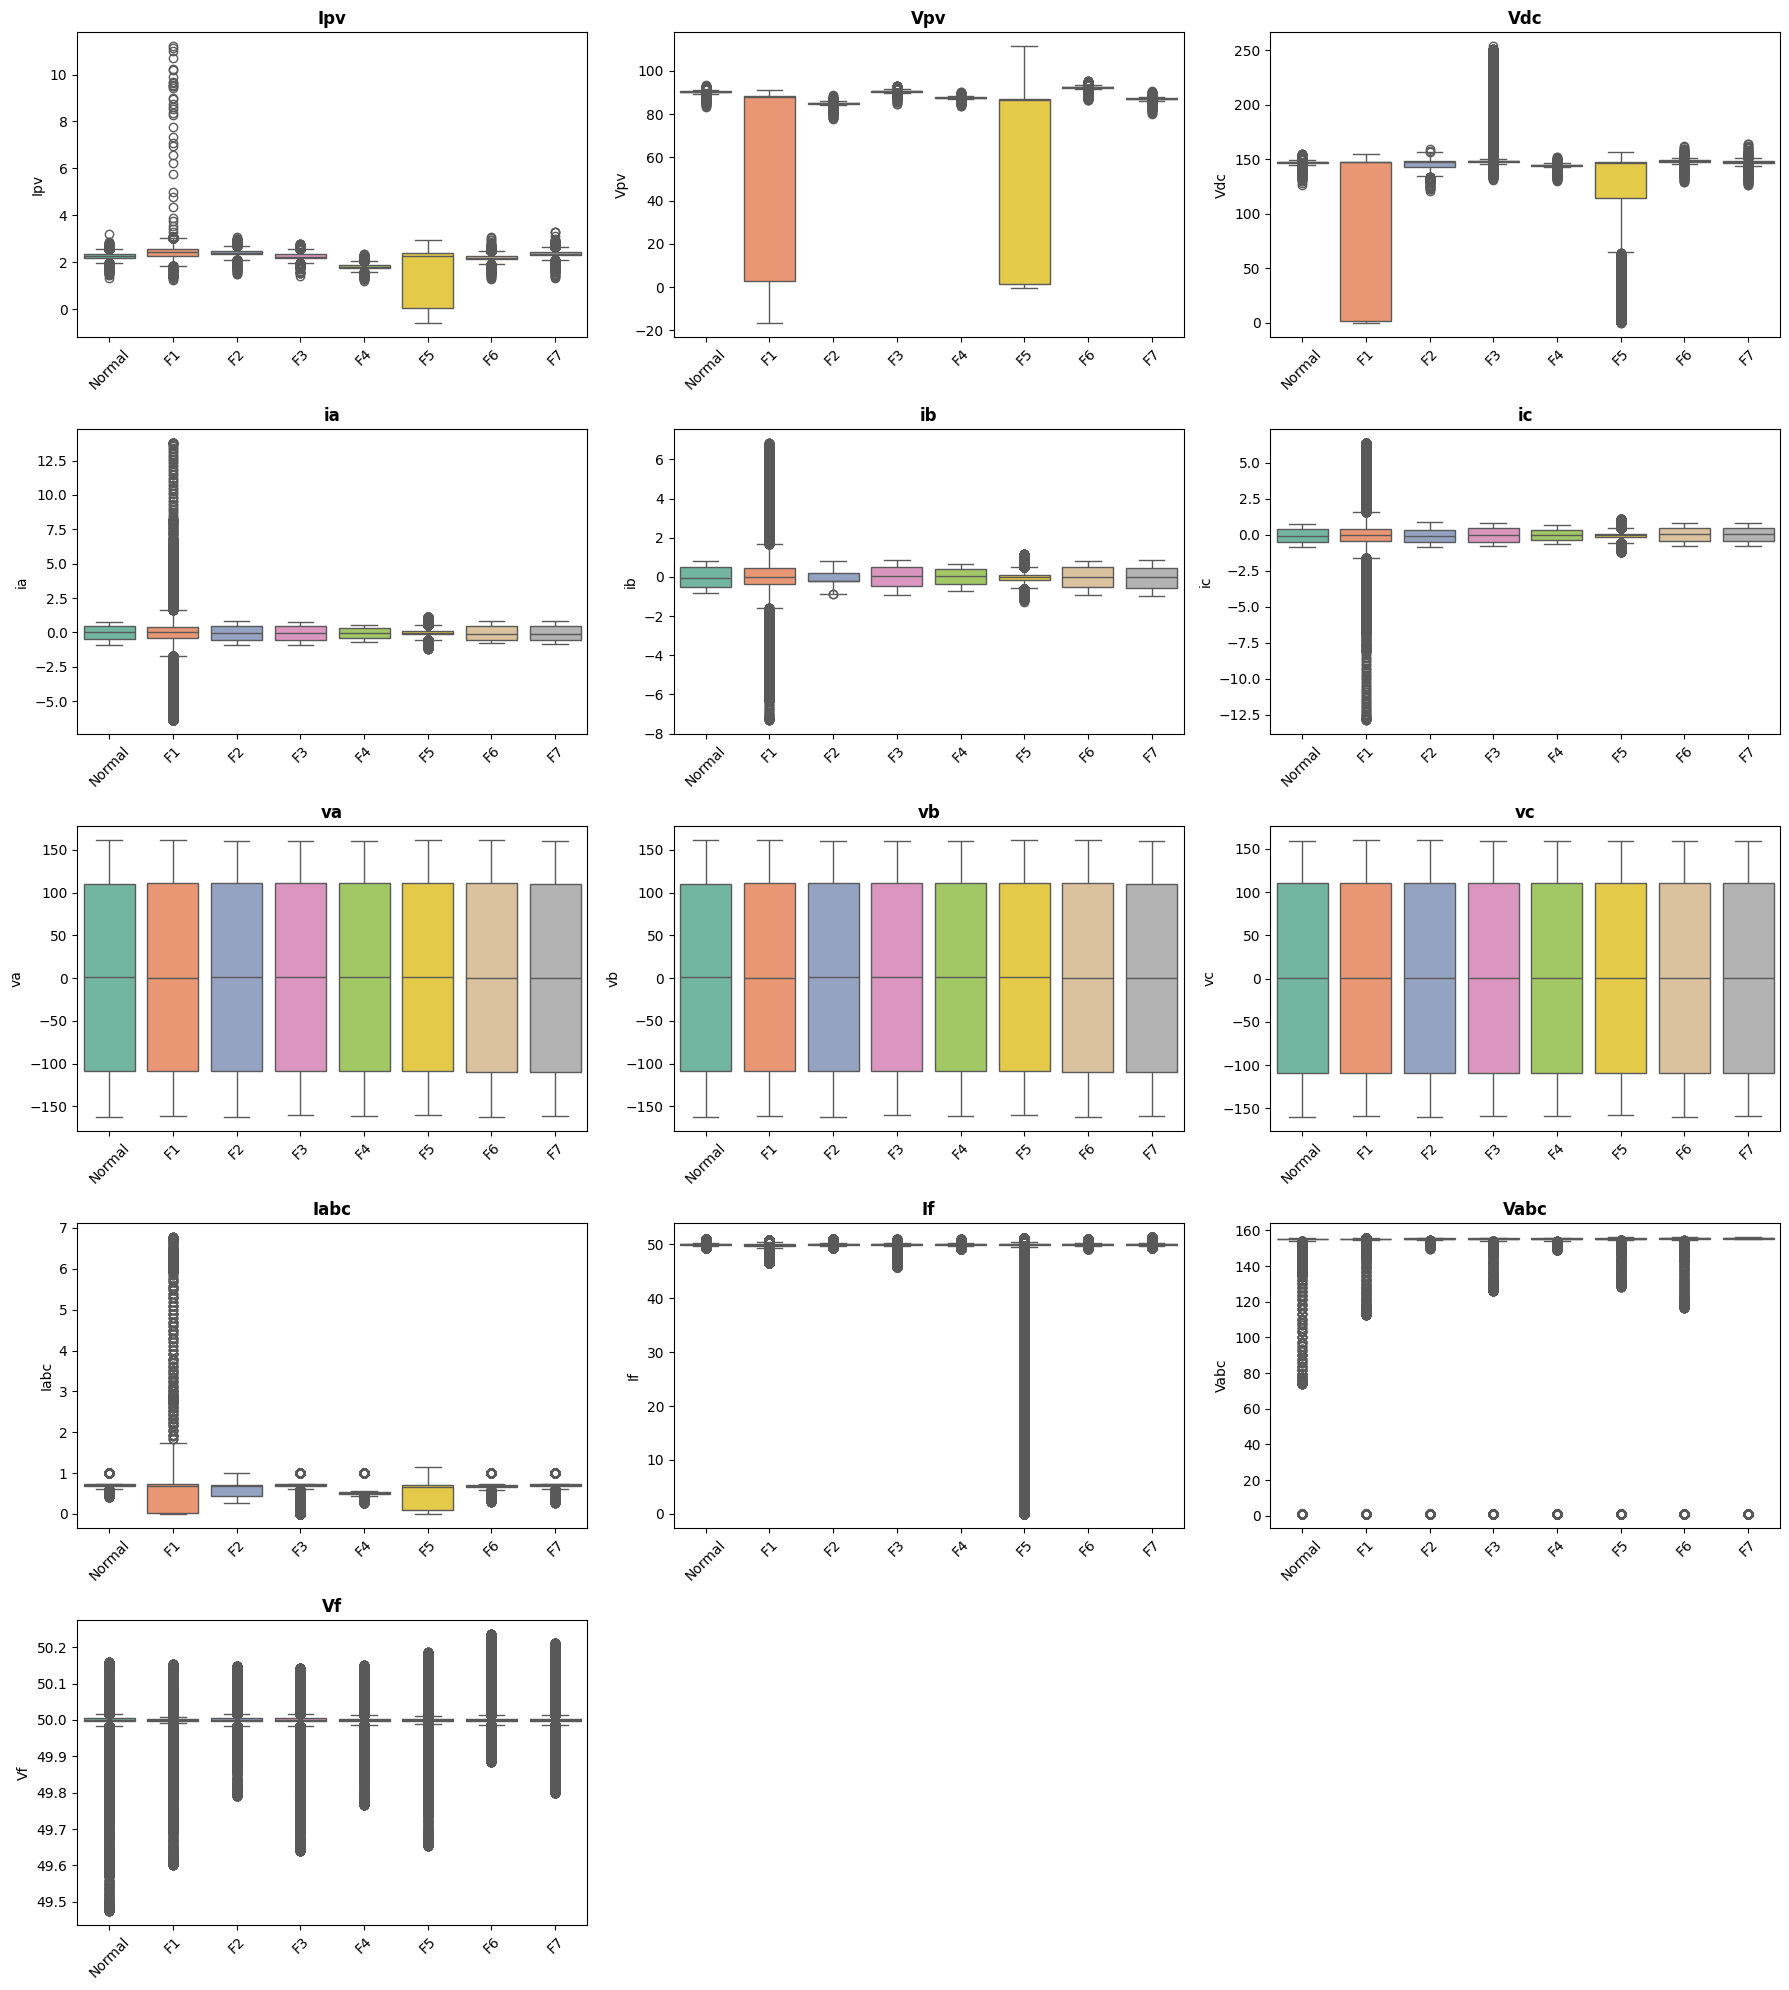

In [4]:
# Grid of boxplots: one subplot per feature
n_cols = 3
n_rows = -(-len(features) // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=df,
        x='Condition',
        y=feature,
        order=condition_order,
        ax=axes[i],
        showfliers=True,   # set False for a cleaner view without outlier noise
        palette='Set2'
    )
    axes[i].set_title(feature, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('gpvs_boxplot_grid_showflier_true.png', dpi=150, bbox_inches='tight')
plt.show()


/tmp/ipykernel_679461/3391189639.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_679461/3391189639.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_679461/3391189639.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_679461/3391189639.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_679461/3391189639.py:9: FutureWarning

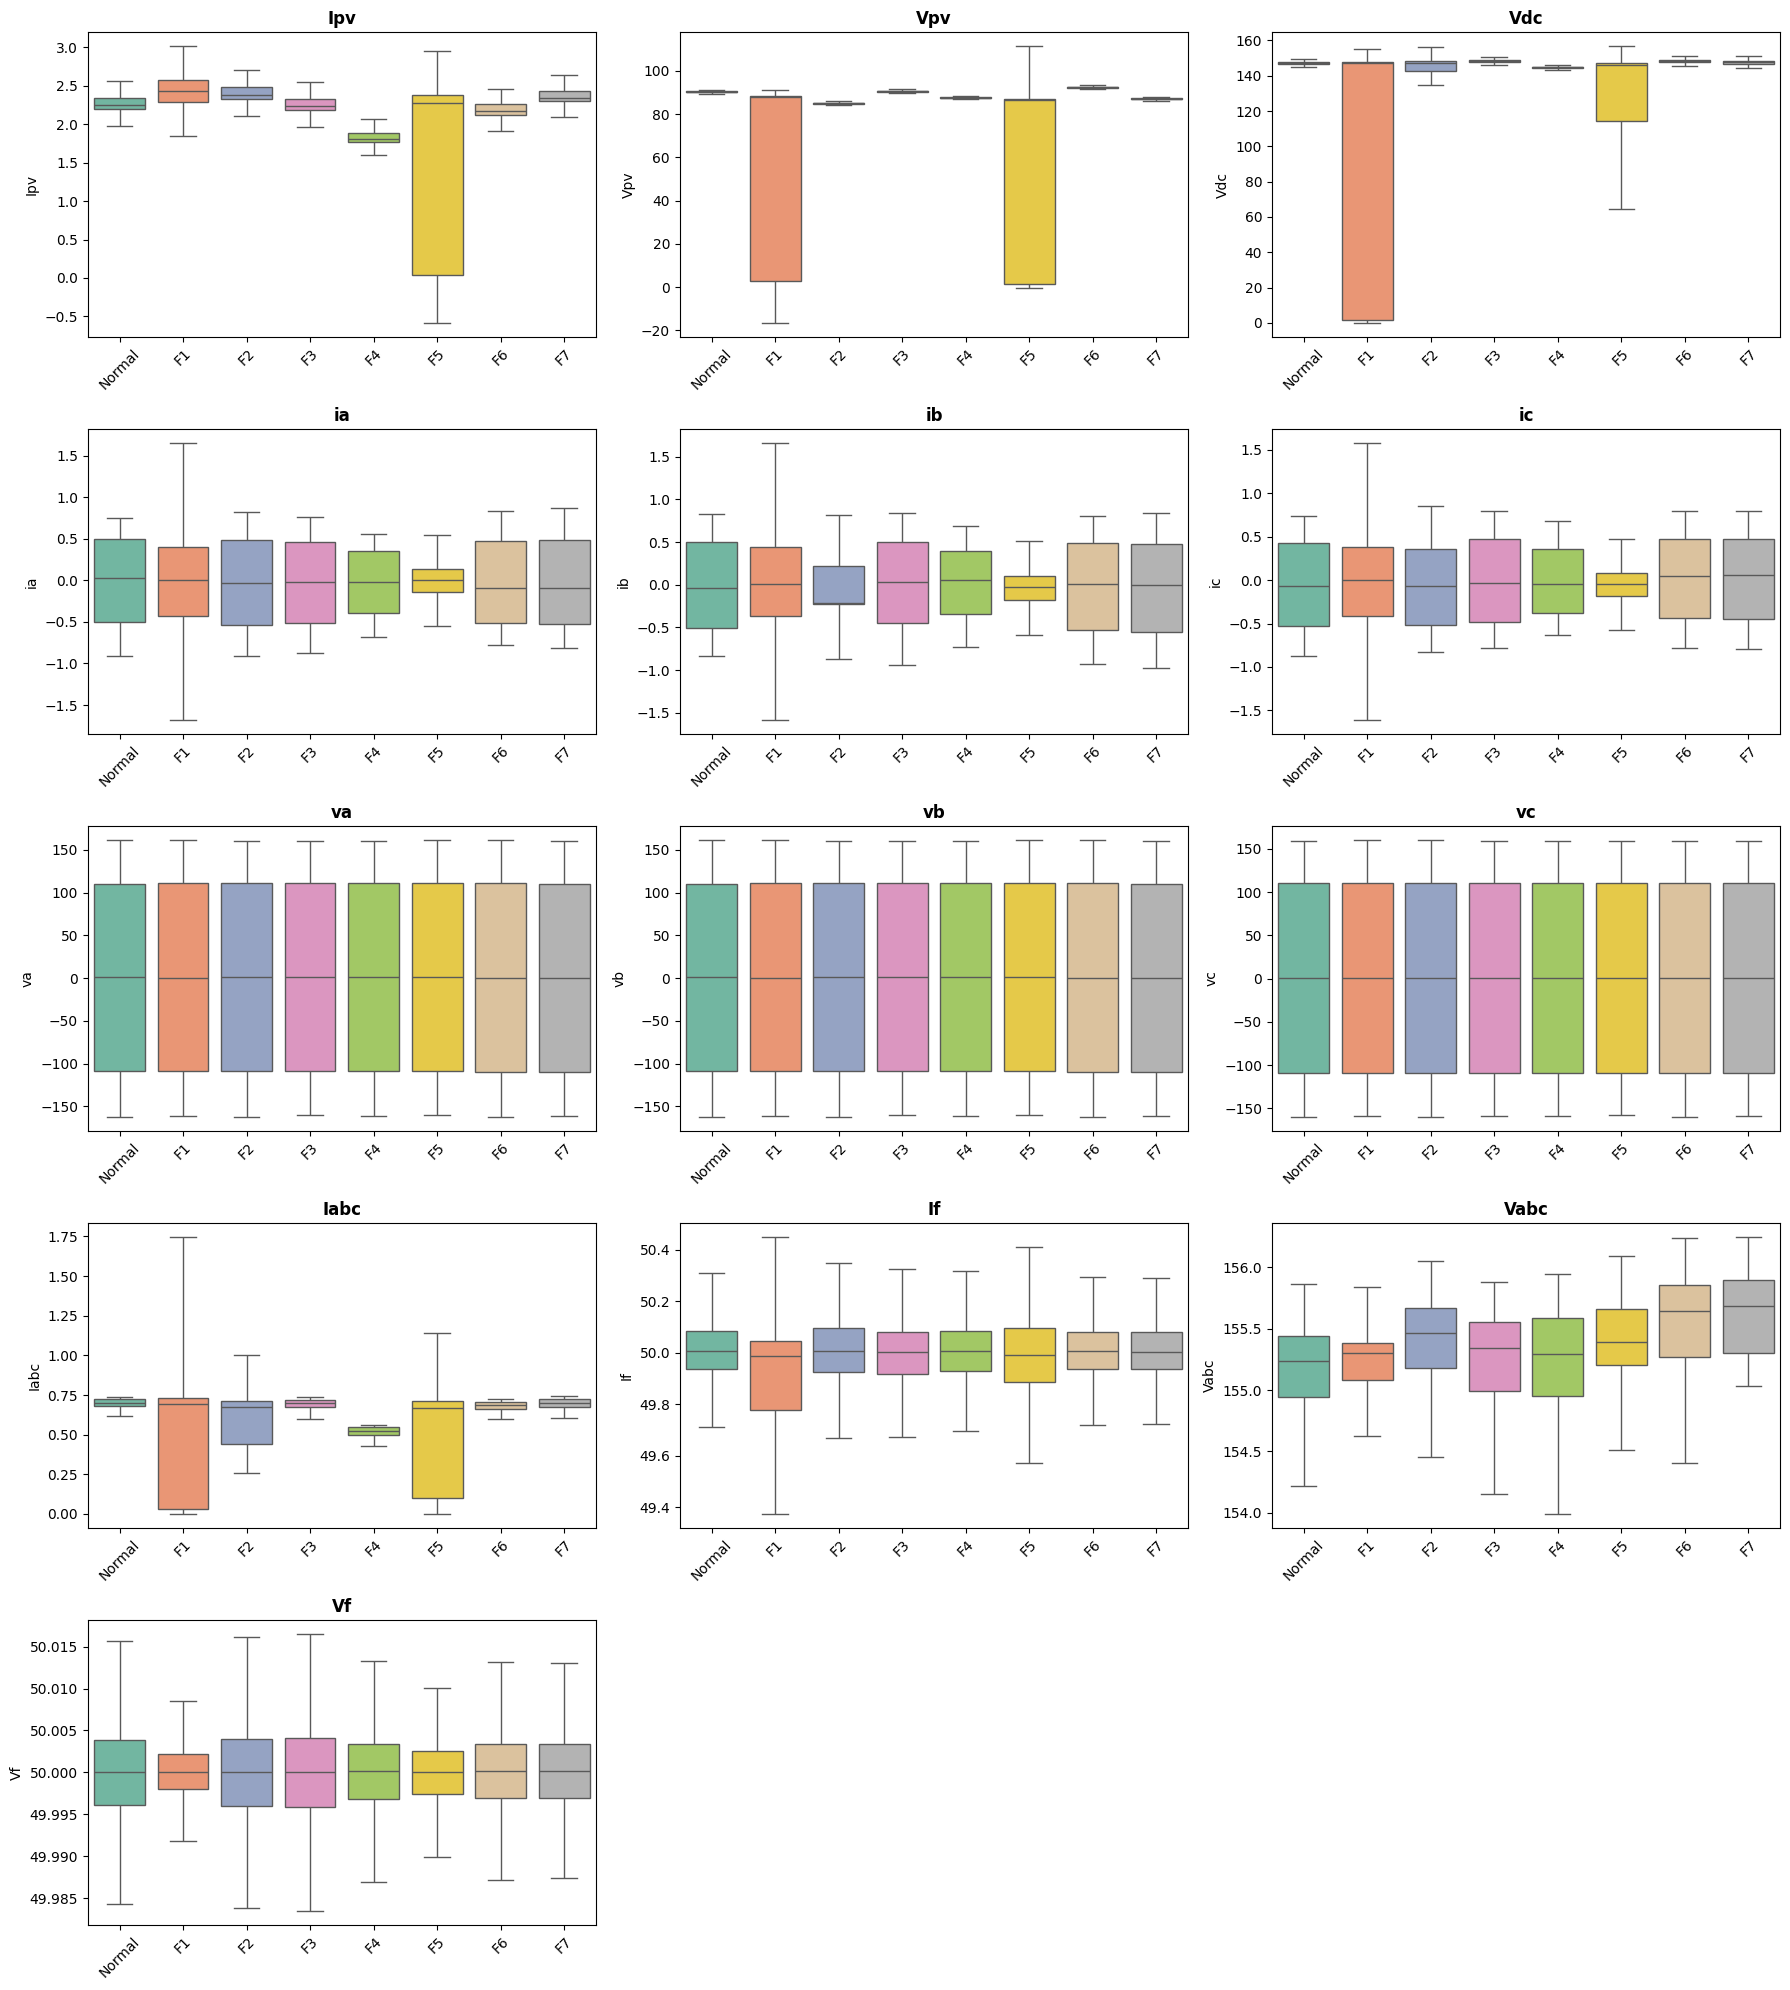

In [5]:
# Grid of boxplots: one subplot per feature
n_cols = 3
n_rows = -(-len(features) // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(
        data=df,
        x='Condition',
        y=feature,
        order=condition_order,
        ax=axes[i],
        showfliers=False,   # set False for a cleaner view without outlier noise
        palette='Set2'
    )
    axes[i].set_title(feature, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

# Remove unused subplots
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('gpvs_boxplot_grid_showflier_false.png', dpi=150, bbox_inches='tight')
plt.show()


# Check for drifts

In [6]:
# --- Setup: isolate and time-order the Normal data ---
normal_df = df[df['Fault'] == 0].sort_values('Time').reset_index(drop=True)

features = ['Ipv', 'Vpv', 'Vdc', 'ia', 'ib', 'ic',
            'va', 'vb', 'vc', 'Iabc', 'If', 'Vabc', 'Vf']

print(f"Normal data: {len(normal_df)} rows, "
      f"Time range {normal_df['Time'].min():.3f}s to {normal_df['Time'].max():.3f}s")

Normal data: 141014 rows, Time range 0.000s to 14.100s


# Visual First Pass

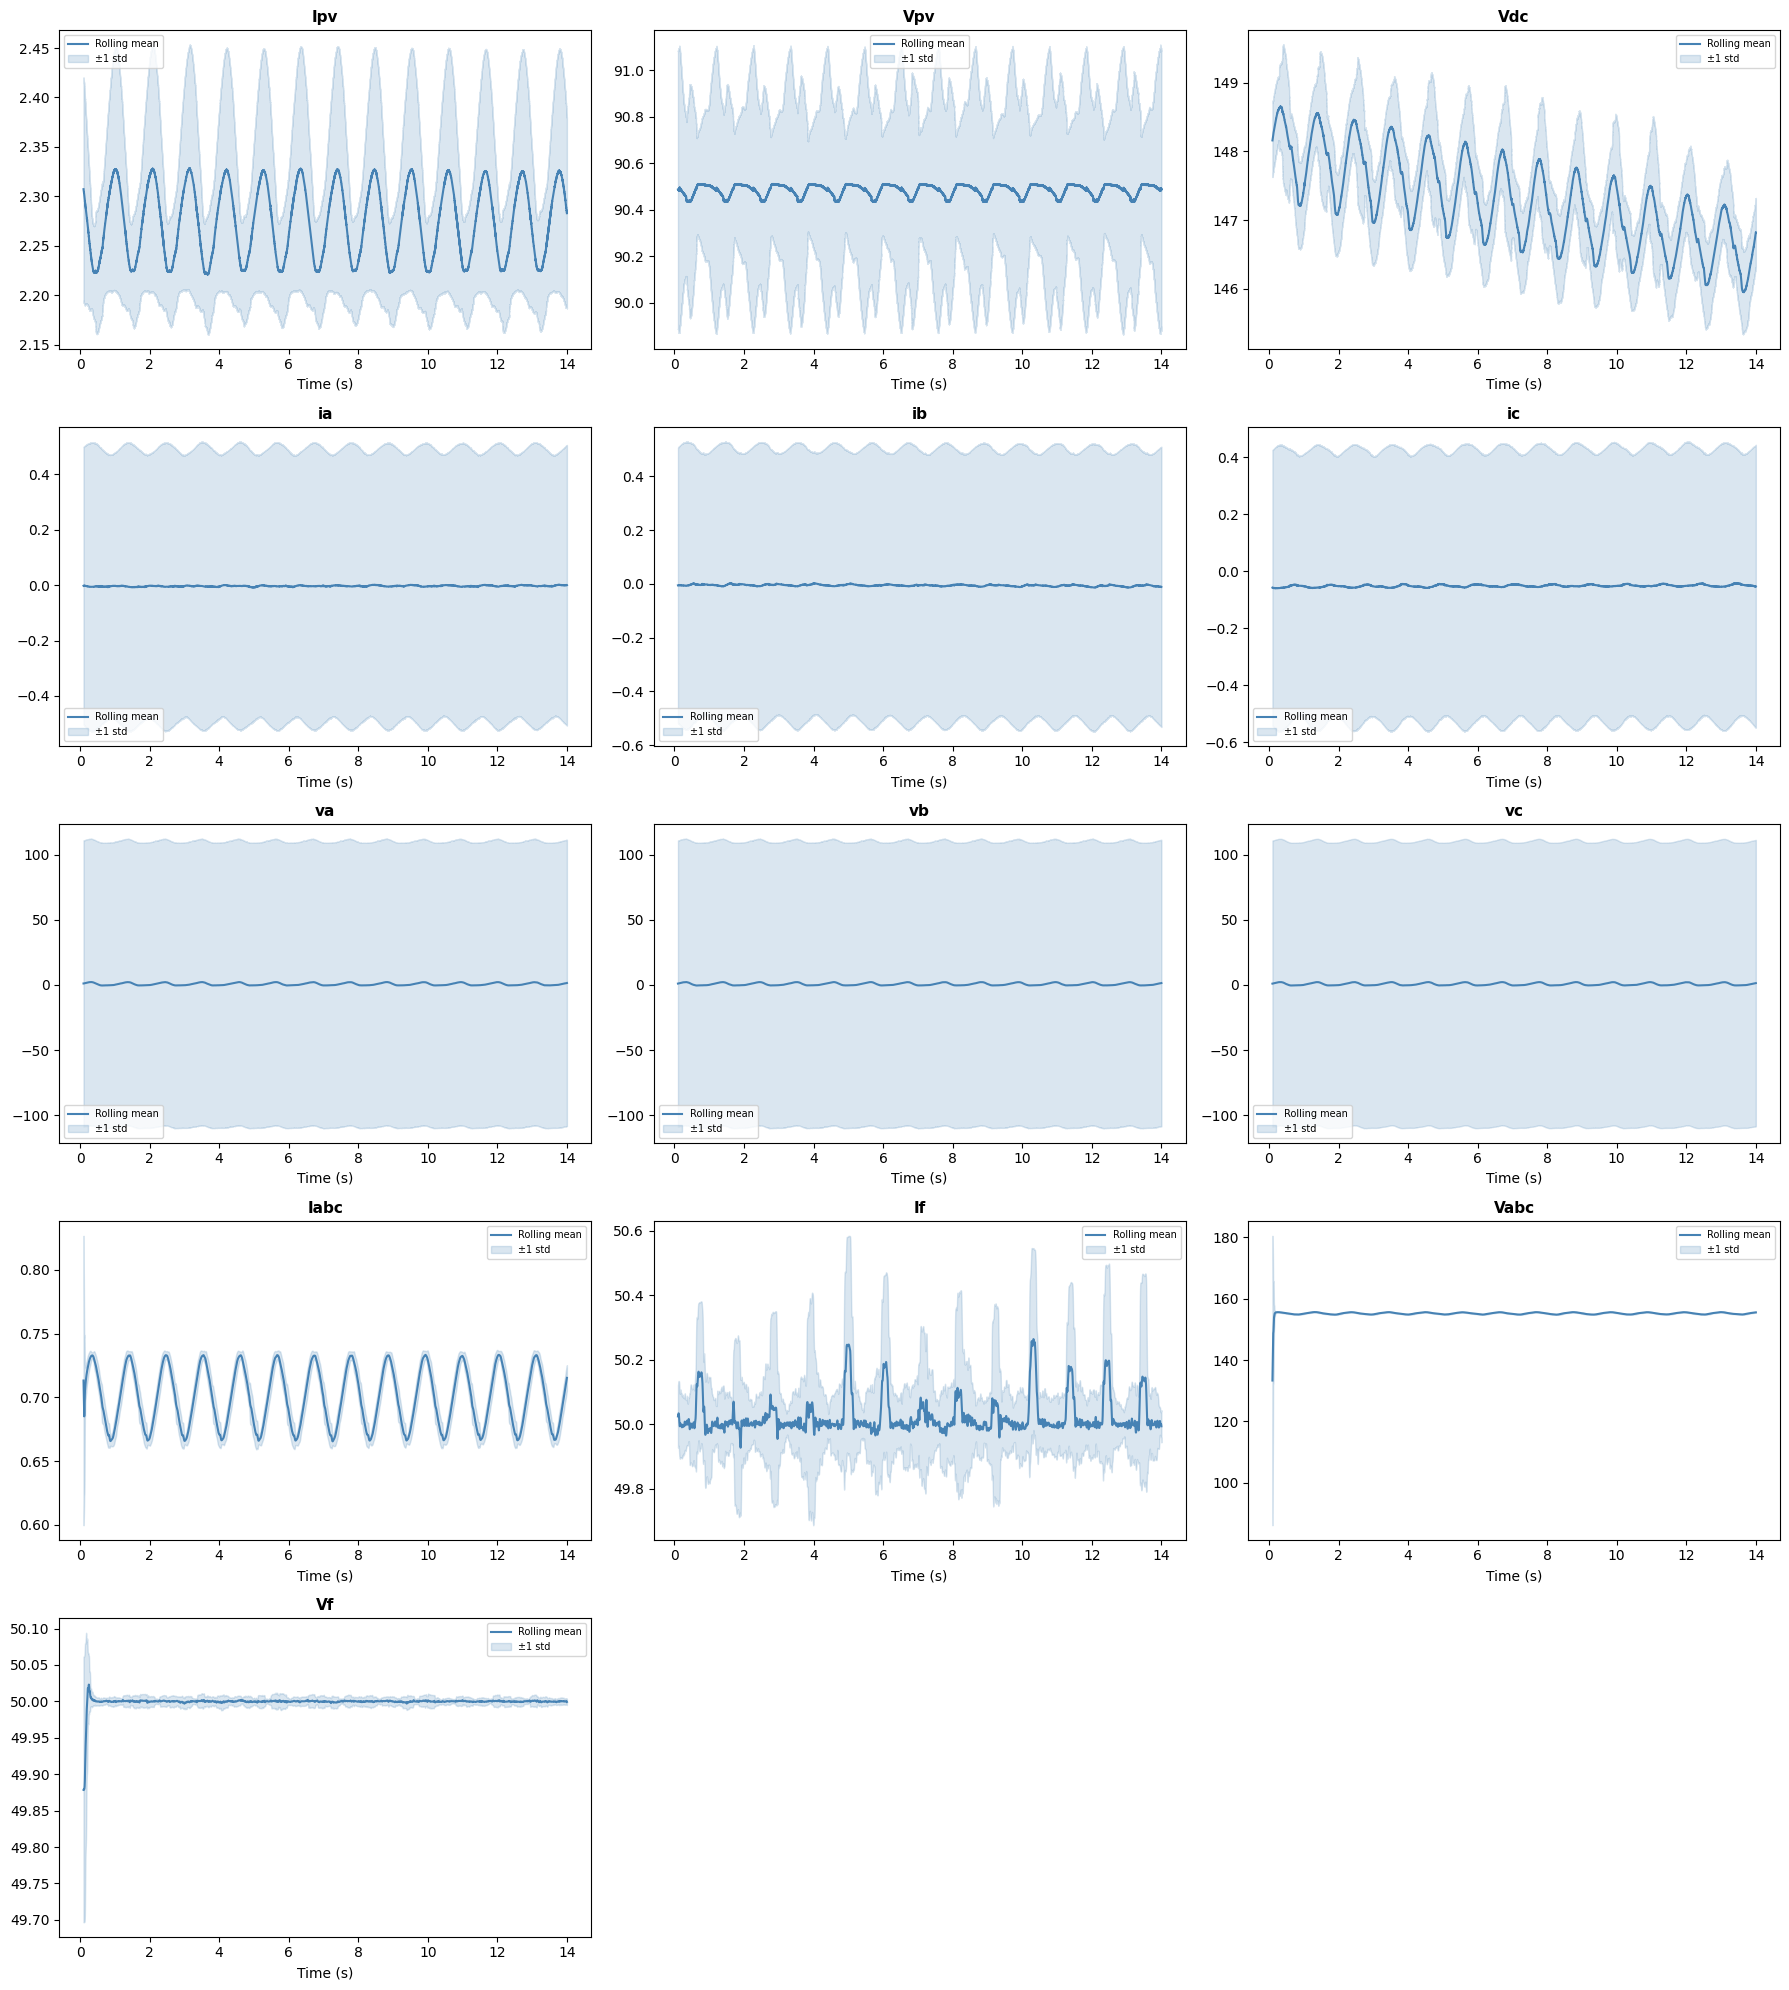

In [7]:
window_size = 2000  # adjust based on your sampling rate; ~0.2s at Ts=100us

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

for i, feature in enumerate(features):
    rolling_mean = normal_df[feature].rolling(window=window_size, center=True).mean()
    rolling_std = normal_df[feature].rolling(window=window_size, center=True).std()

    ax = axes[i]
    ax.plot(normal_df['Time'], rolling_mean, color='steelblue', label='Rolling mean')
    ax.fill_between(normal_df['Time'],
                     rolling_mean - rolling_std,
                     rolling_mean + rolling_std,
                     color='steelblue', alpha=0.2, label='±1 std')
    ax.set_title(feature, fontsize=11, fontweight='bold')
    ax.set_xlabel('Time (s)')
    ax.legend(fontsize=7)

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('normal_rolling_stability.png', dpi=150, bbox_inches='tight')
plt.show()

# Formal test — chunk-based KS and Wasserstein distance

In [8]:
from scipy.stats import ks_2samp, wasserstein_distance

# Split the time-ordered stream into thirds
n = len(normal_df)
chunk1 = normal_df.iloc[:n // 3]
chunk2 = normal_df.iloc[n // 3: 2 * n // 3]
chunk3 = normal_df.iloc[2 * n // 3:]

results = []
for feature in features:
    ks_stat_13, p_13 = ks_2samp(chunk1[feature], chunk3[feature])
    wd_13 = wasserstein_distance(chunk1[feature], chunk3[feature])

    # Also check adjacent chunks (1 vs 2, 2 vs 3) to see if drift is gradual or a jump
    ks_stat_12, p_12 = ks_2samp(chunk1[feature], chunk2[feature])
    ks_stat_23, p_23 = ks_2samp(chunk2[feature], chunk3[feature])

    results.append({
        'feature': feature,
        'KS(1v3)': ks_stat_13, 'p(1v3)': p_13,
        'Wasserstein(1v3)': wd_13,
        'KS(1v2)': ks_stat_12,
        'KS(2v3)': ks_stat_23,
    })

drift_check_df = pd.DataFrame(results).sort_values('KS(1v3)', ascending=False)
print(drift_check_df.to_string(index=False))

feature  KS(1v3)       p(1v3)  Wasserstein(1v3)  KS(1v2)  KS(2v3)
    Vdc 0.553299 0.000000e+00          1.088548 0.320193 0.273141
     Vf 0.067273 6.379755e-93          0.007689 0.030934 0.059079
   Vabc 0.051316 3.150643e-54          0.947843 0.071022 0.082034
   Iabc 0.046935 1.977544e-45          0.003693 0.053384 0.024231
     If 0.038094 4.547694e-30          0.020612 0.042647 0.049101
    Ipv 0.019779 2.035220e-08          0.003528 0.013130 0.028976
     ia 0.014213 1.488737e-04          0.003331 0.009703 0.004999
    Vpv 0.009396 3.133623e-02          0.004747 0.016151 0.016445
     ib 0.006745 2.342645e-01          0.003544 0.005958 0.003000
     ic 0.005755 4.161876e-01          0.003952 0.003917 0.005042
     vc 0.003447 9.418651e-01          0.166098 0.004298 0.002829
     va 0.002589 9.973938e-01          0.268032 0.003830 0.003212
     vb 0.002589 9.973938e-01          0.269005 0.003830 0.003212


# Streaming drift detector — ADWIN

In [9]:
# pip install river --break-system-packages   (if not already installed)
from river.drift import ADWIN

adwin_results = {}

for feature in features:
    adwin = ADWIN()
    drift_points = []

    for idx, value in enumerate(normal_df[feature].values):
        adwin.update(value)
        if adwin.drift_detected:
            drift_points.append(normal_df['Time'].iloc[idx])

    adwin_results[feature] = drift_points
    print(f"{feature}: {len(drift_points)} drift point(s) detected"
          + (f" — first at t={drift_points[0]:.3f}s" if drift_points else ""))

Ipv: 53 drift point(s) detected — first at t=0.218s
Vpv: 26 drift point(s) detected — first at t=0.893s
Vdc: 461 drift point(s) detected — first at t=0.016s
ia: 1410 drift point(s) detected — first at t=0.010s
ib: 1410 drift point(s) detected — first at t=0.010s
ic: 1409 drift point(s) detected — first at t=0.013s
va: 3522 drift point(s) detected — first at t=0.006s
vb: 3531 drift point(s) detected — first at t=0.003s
vc: 3542 drift point(s) detected — first at t=0.003s
Iabc: 62 drift point(s) detected — first at t=0.026s
If: 442 drift point(s) detected — first at t=0.038s
Vabc: 265 drift point(s) detected — first at t=0.022s
Vf: 6 drift point(s) detected — first at t=0.038s


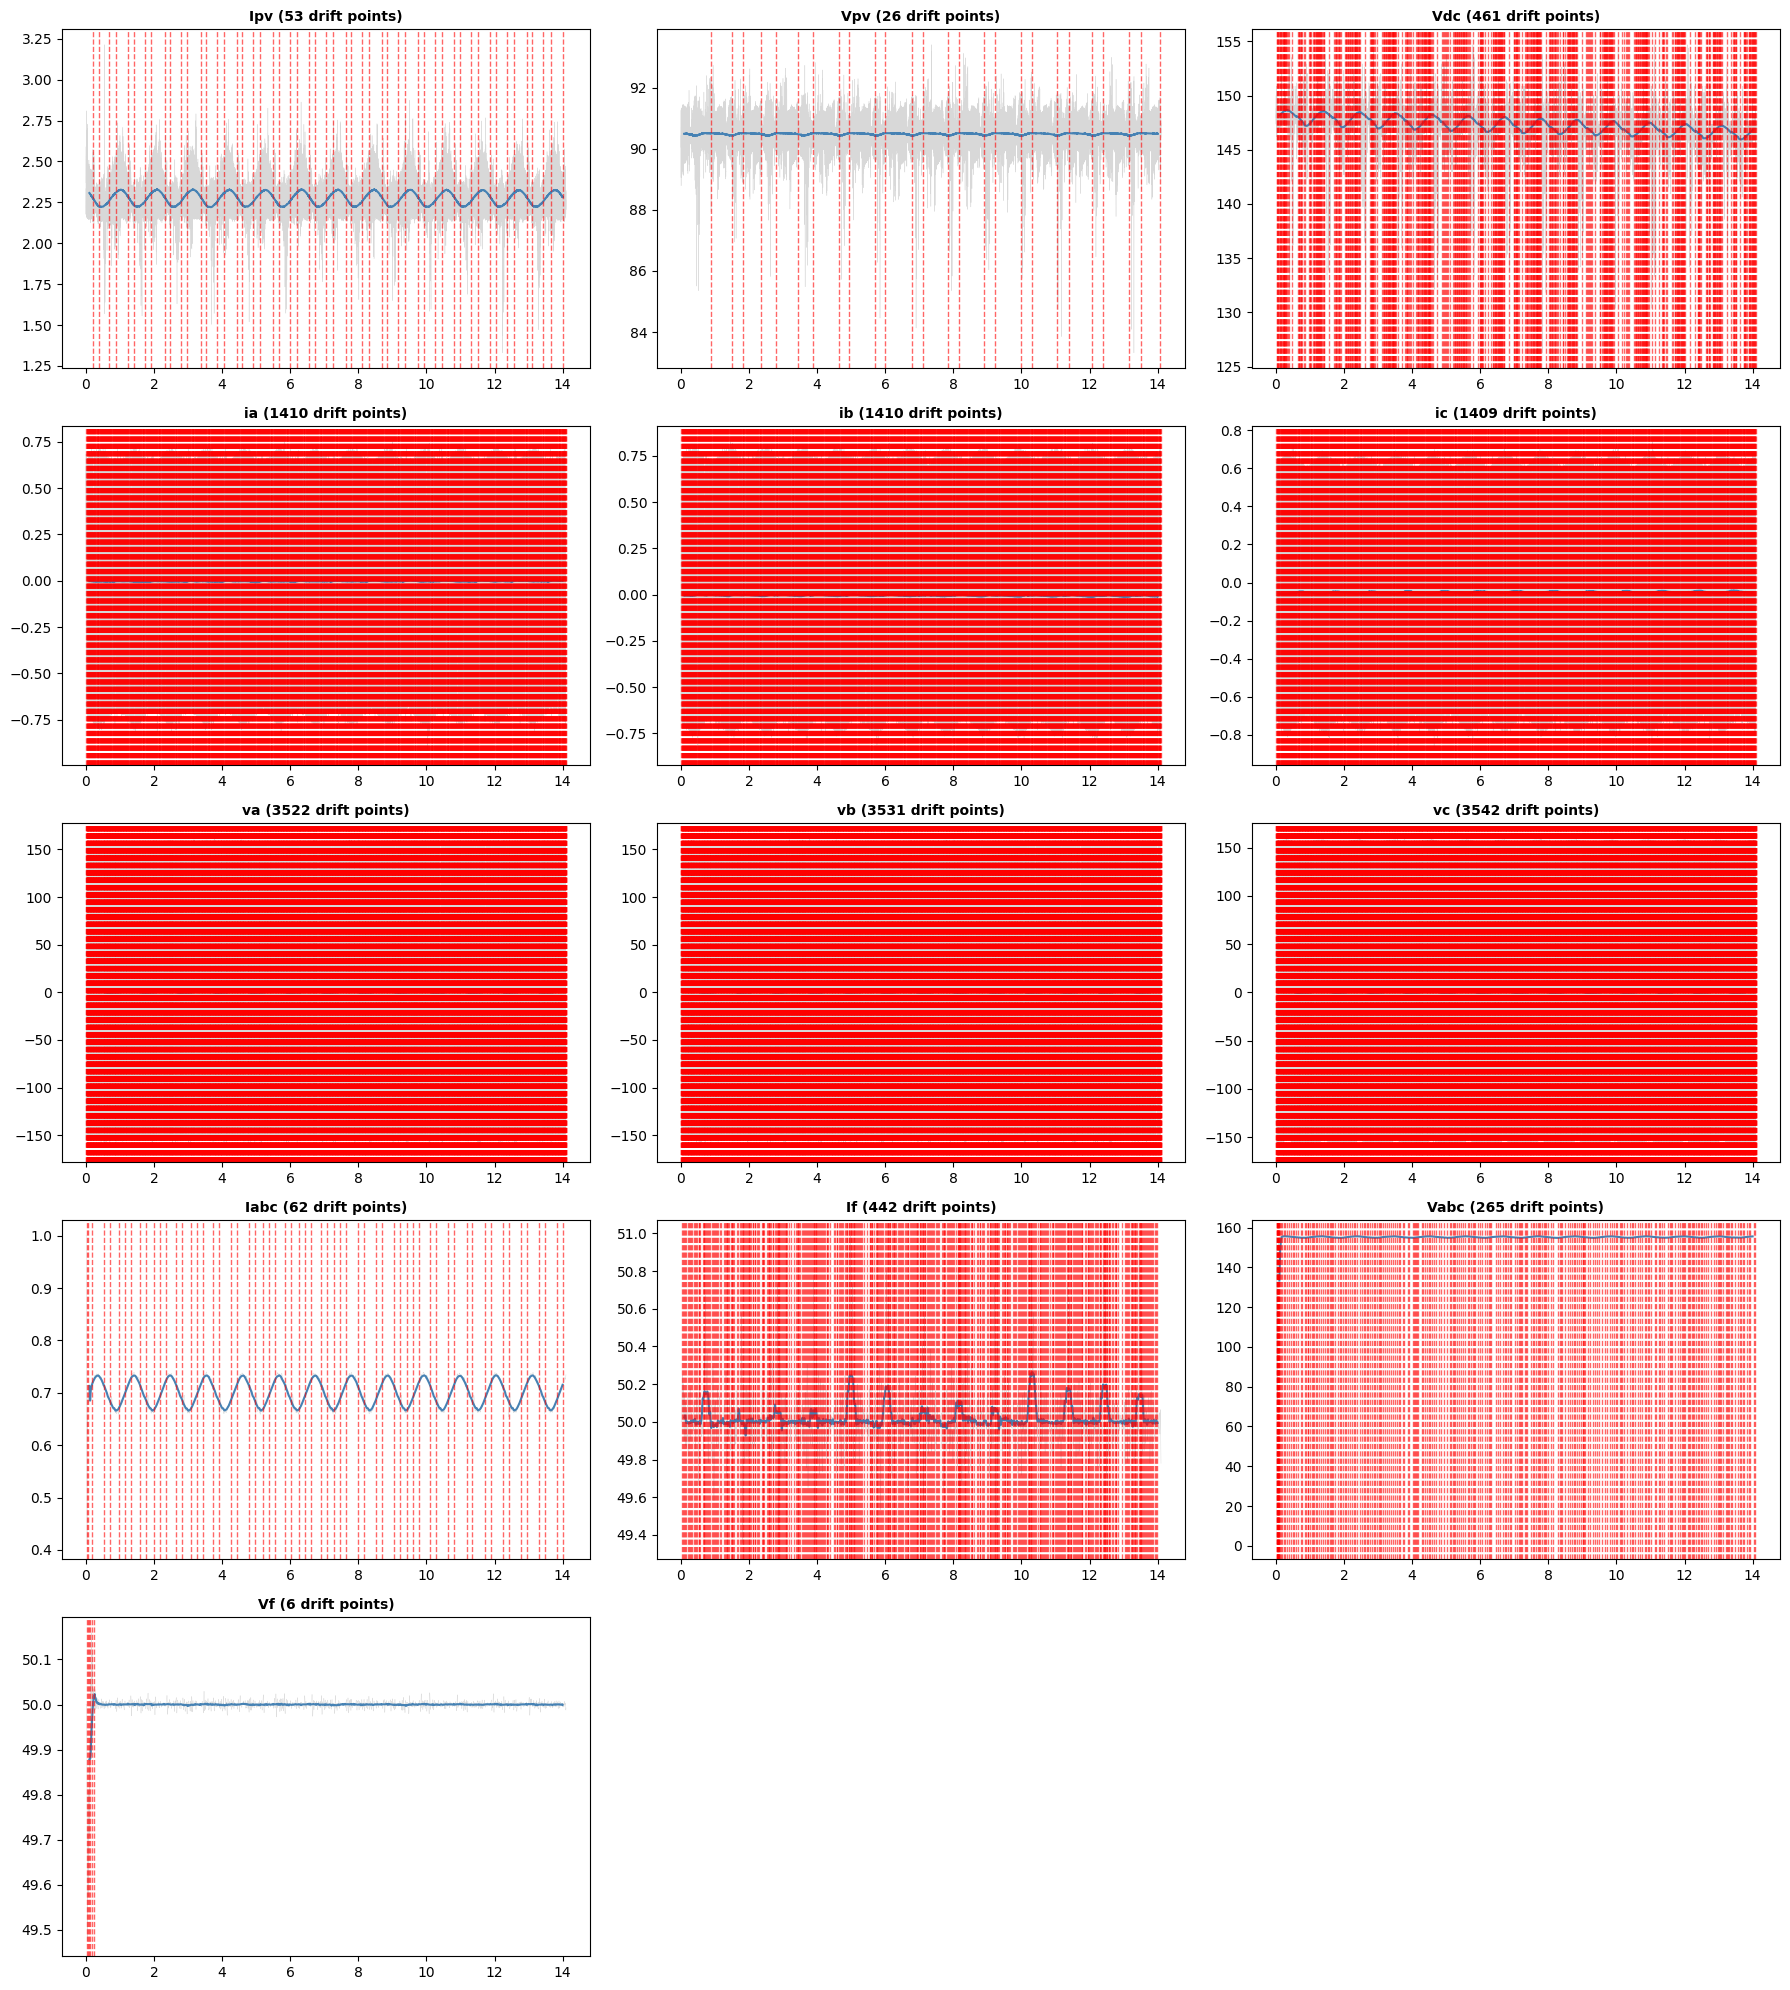

In [10]:
fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]
    ax.plot(normal_df['Time'], normal_df[feature], alpha=0.3, linewidth=0.3, color='gray')
    rolling_mean = normal_df[feature].rolling(window=window_size, center=True).mean()
    ax.plot(normal_df['Time'], rolling_mean, color='steelblue')

    for dp in adwin_results[feature]:
        ax.axvline(dp, color='red', linestyle='--', alpha=0.6, linewidth=1)

    ax.set_title(f"{feature} ({len(adwin_results[feature])} drift points)",
                 fontsize=10, fontweight='bold')

for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('normal_adwin_driftpoints.png', dpi=150, bbox_inches='tight')
plt.show()